https://share.google/aimode/FqcB97Hliaz1Niaft

# transformers, sinusoidal positional encoding. how it works

In transformer architectures, sinusoidal positional encoding is a method used to inject information about the order of tokens in a sequence. Because transformers process all tokens in parallel, they lack an inherent sense of sequential order (unlike RNNs) and would treat a sentence as an unordered "bag of words" without this encoding. [1, 2] 

**How the Formula Works**

The original [Attention Is All You Need](https://arxiv.org/abs/1706.03762) paper uses fixed sine and cosine functions of different frequencies to create a unique vector for every position: [3, 4, 5, 6] 

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$ 
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$ 

* $pos$: The position of the token in the sequence (0, 1, 2, ...).
* $i$: The index within the embedding vector dimension.
* $d_{model}$: The total dimensionality of the model's embeddings (e.g., 512). [4, 5, 7, 8, 9] 

**Key Mechanics and Intuition**

* Multi-Scale Representation: Think of it like a binary counter but with smooth waves. Lower dimensions oscillate rapidly (high frequency) to capture local, fine-grained relationships, while higher dimensions oscillate slowly (low frequency) to capture global, long-range structure.
* Relative Position Awareness: Because sine and cosine are used, the encoding for $pos + k$ can be represented as a linear transformation of the encoding for $pos$. This allows the self-attention mechanism to learn and attend to relative distances between tokens easily.
* Uniqueness: By combining multiple frequencies across the embedding dimensions, every position in a sequence receives a unique "fingerprint" or signature.
* Fixed and Non-Trainable: Unlike "learned" positional embeddings, these are deterministic and require no extra parameters, which helps the model generalize to sequence lengths longer than those seen during training. [3, 5, 10, 11, 12, 13, 14, 15, 16, 17, 18] 

**Implementation Detail**

These positional vectors have the same dimension as the word embeddings, so they are simply added together before being fed into the first attention layer. This allows the model to distinguish between "The dog bites the man" and "The man bites the dog" by "tagging" each word with its location. [1, 3, 19, 20, 21] 

Would you like to see a Python implementation of these formulas or a comparison with modern alternatives like Rotary Positional Encodings (RoPE)?

[1] [https://www.ibm.com](https://www.ibm.com/think/topics/positional-encoding)
[2] [https://medium.com](https://medium.com/@adnaan525/the-intuition-behind-sinusoidal-positional-encoding-in-transformers-ac13268a60b4)
[3] [https://medium.com](https://medium.com/thedeephub/positional-encoding-explained-a-deep-dive-into-transformer-pe-65cfe8cfe10b)
[4] [https://www.youtube.com](https://www.youtube.com/watch?v=bQCQ7VO-TWU&t=506)
[5] [https://medium.com](https://medium.com/@lixue421/understanding-positional-encoding-in-transformers-2c7336728be5)
[6] [https://medium.com](https://medium.com/@hunter-j-phillips/positional-encoding-7a93db4109e6#:~:text=To%20ensure%20each%20position%20has%20a%20unique,are%20a%20few%20reasons%20why%20its%20useful.)
[7] [https://medium.com](https://medium.com/@robin5002234/understanding-the-transformer-architecture-a-deep-dive-6e463f4f9649#:~:text=pos%20is%20the%20position%20of%20the%20token,1%20for%20the%20second%2C%20and%20so%20on%29.)
[8] [https://www.linkedin.com](https://www.linkedin.com/pulse/positional-embedding-transformers-intuition-alex-louizos-5pccf#:~:text=Sequence%20positions:%200%2C%201%2C%202)
[9] [https://medium.com](https://medium.com/@samhitha.muvva/if-youre-here-that-means-you-re-halfway-through-the-attention-is-all-you-need-paper-and-found-c714c3f21c38#:~:text=The%20Almost%2DMath%20Behind%2010%2C000%20in%20Positional%20Encoding:,d_model%20is%20the%20embedding%20dimension%20%28typically%20512%29)
[10] [https://mesuvash.github.io](https://mesuvash.github.io/blog/2026/positional-encodings/)
[11] [https://medium.com](https://medium.com/@lepicardhugo/how-transformers-encode-position-pe-rope-made-simple-024d5e03fa03#:~:text=The%20Intuition:%20From%20Binary%20Bits%20to%20Frequencies,a%20unique%20binary%20representation%20for%20each%20number.)
[12] [https://www.youtube.com](https://www.youtube.com/watch?v=dWkm4nFikgM)
[13] [https://medium.com](https://medium.com/the-software-frontier/deep-dive-into-transformer-positional-encoding-a-comprehensive-guide-5adcded5a38d)
[14] [https://arxiv.org](https://arxiv.org/pdf/2506.06398)
[15] [https://medium.com](https://medium.com/@xsunsmile/demystifying-positional-encoding-in-transformers-why-sine-and-cosine-functions-work-572ba2dd7e14#:~:text=By%20combining%20sine%20and%20cosine%20waves%20of,ensures%20uniqueness%20across%20all%20practical%20sequence%20lengths.)
[16] [https://www.storminthecastle.com](https://www.storminthecastle.com/posts/01_position_problem_sinusoidal/)
[17] [https://medium.com](https://medium.com/@charlesduyilemi/understanding-positional-encoding-in-transformers-a-friendly-guide-380f1948036e#:~:text=Why%20This%20Works%20*%20Unique%20Positional%20Signatures:,during%20training%20%28thanks%20to%20predictable%20sine/cosine%20behavior%29.)
[18] [https://medium.com](https://medium.com/@xiaxiami/understanding-positional-encoding-in-transformer-and-large-language-models-58f1d9a713ed#:~:text=1.%20Sinusoidal%20Positional%20Encoding%20%28Vaswani%20et%20al.%2C,vector%20using%20sinusoidal%20functions%20of%20different%20frequencies.)
[19] [https://www.byhand.ai](https://www.byhand.ai/p/pytorchexcel-sinusoidal-positional)
[20] [https://medium.com](https://medium.com/@hirok4/understanding-transformer-sinusoidal-position-embedding-7cbaaf3b9f6a)
[21] [https://www.geeksforgeeks.org](https://www.geeksforgeeks.org/nlp/positional-encoding-in-transformers/#:~:text=Positional%20encoding%20is%20a%20technique%20that%20adds,would%20struggle%20to%20process%20sequential%20data%20effectively.)


# I'm trying to understand following phenomen:
```
d_model = 256
min_timescale = 2
max_timescale = 1000
pos = 15

freqs = torch.arange(0, d_model, min_timescale)
inv_freqs = max_timescale ** (-freqs / d_model)
seq = torch.arange(pos - 1, -1, -1.0)
sinusoidal_inp = pos * inv_freqs
pos_emb = torch.cat((sinusoidal_inp.sin(), sinusoidal_inp.cos()), dim=-1)

torch.linalg.vector_norm(pos_emb)
```
No matter which position I'm trying to encode I always get the same vector norm = 11.3137

---

The reason the norm is constant (11.3137) is due to the Pythagorean identity: $\sin^2(\theta) + \cos^2(\theta) = 1$.

In your code, you are calculating a set of frequencies and then creating a vector that concatenates all the sine components followed by all the cosine components. When you calculate the vector_norm, the math looks like this:

   1. The Components: For every frequency index $i$, you have a value $x_i$ (your sinusoidal_inp).
   2. The Vector: Your pos_emb is $[ \sin(x_0), \sin(x_1), \dots, \sin(x_{127}), \cos(x_0), \cos(x_1), \dots, \cos(x_{127}) ]$.
   3. The Squared Norm:
   $$\Vert{}pos\_emb\Vert{}^2 = \sum_{i=0}^{127} \sin^2(x_i) + \sum_{i=0}^{127} \cos^2(x_i)$$ 
   Grouping them by frequency:
   $$\Vert{}pos\_emb\Vert{}^2 = \sum_{i=0}^{127} (\sin^2(x_i) + \cos^2(x_i))$$ 
   4. The Result: Since each $(\sin^2 + \cos^2)$ pair equals 1, the sum is simply the count of frequency pairs.
   * d_model = 256
      * Pairs = d_model / 2 = 128
      * $\text{Norm} = \sqrt{128} \approx \mathbf{11.3137}$
   
**Why is this useful?**

This property is actually a feature, not a bug. By keeping the norm constant:

* Scale Invariance: The "energy" or magnitude of the positional signal doesn't change regardless of how far into the sequence a token is.
* Stable Training: When you add this to your word embeddings, it doesn't push the resulting vector into a different numerical range, which helps keep gradients stable.

**Quick Check:** If you change your d_model to 512, you'll see your norm change to $\sqrt{256} = 16$.

Would you like to see how this constant norm affects the dot-product attention between two different positions?



# Let's check it out!

When you look at the dot product between two positional encodings, you see how the constant norm creates a perfect similarity metric based purely on distance.

Because the norm is always $\sqrt{d_{model}/2}$, the dot product is effectively a measure of the relative distance between tokens.

**1. Distance Sensitivity**

The dot product between two positions $pos$ and $pos + k$ depends only on the offset $k$, not the absolute value of $pos$.

* Nearby tokens (e.g., pos 15 and 16) have highly correlated sine/cosine waves, resulting in a high dot product.
* Distant tokens (e.g., pos 15 and 100) have decorrelated waves, causing the dot product to decay toward zero.

**2. The Trigonometric Expansion**

When you dot product two vectors $PE_{pos}$ and $PE_{pos+k}$, you are summing:
$$\sum_{i} \left( \sin(\theta_{i, pos}) \sin(\theta_{i, pos+k}) + \cos(\theta_{i, pos}) \cos(\theta_{i, pos+k}) \right)$$ 
Using the angle subtraction identity $\cos(A - B) = \cos(A)\cos(B) + \sin(A)\sin(B)$, this simplifies to:
$$\sum_{i} \cos(\theta_{i, pos+k} - \theta_{i, pos})$$ 

**3. Visualizing the Decay**

Because the frequencies decrease geometrically, the dot product looks like a sharp peak that smoothens out.
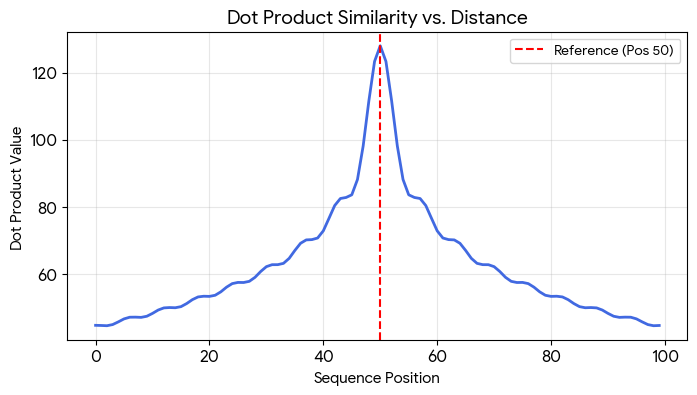

**Summary**

* Max Value: When $pos_1 = pos_2$, the dot product is exactly $d_{model}/2$ (which is $128$ in your case).
* Locality: The model "sees" that tokens are close to each other because their positional vectors overlap significantly in vector space.
* Symmetry: The similarity between pos 15 and 20 is the same as between pos 50 and 55.

Do you want to see how Rotary Embeddings (RoPE) improve on this by applying a rotation instead of an addition?



# Let's check it out

Rotary Positional Embeddings (RoPE) take the math you just explored—specifically the property of relative similarity via rotation—and make it the core mechanism rather than just a side effect. [1, 2] 

While sinusoidal encodings are additive (you add a static vector to the word embedding), RoPE is multiplicative. It treats your vector dimensions in pairs and "rotates" them in a 2D plane by an angle that depends on their position. [3, 4, 5, 6] 

**1. The Core Intuition: "Position as Rotation"**

Think of every token as a set of needles on a clock face. Instead of adding a constant to the needle's position, we rotate the needles. [7, 8] 

* Token A at position $m$ is rotated by $\theta \cdot m$.
* Token B at position $n$ is rotated by $\theta \cdot n$.
* The dot product (attention score) between them then only depends on the difference in their angles: $\theta(m - n)$. [9, 10] 

This ensures that the attention mechanism is purely relative—the model cares how far apart tokens are, not where they are in the absolute sequence. [2, 11] 

**2. The Formulation**

RoPE splits a $d$-dimensional vector into $d/2$ pairs. For each pair $(x_1, x_2)$, it applies a 2D rotation matrix: [9, 12, 13] 
$$\begin{pmatrix} x^{(m)}_1 \\ x^{(m)}_2 \end{pmatrix} = \begin{pmatrix} \cos(m\theta) & -\sin(m\theta) \\ \sin(m\theta) & \cos(m\theta) \end{pmatrix} \begin{pmatrix} x_1 \\ x_2 \end{pmatrix}$$ 

Where $m$ is the position and $\theta$ is a frequency that varies across dimensions (exactly like the frequencies in your code). [14, 15] 

**3. Why RoPE Beat Sinusoidal Encodings**

Modern LLMs like Llama 3 and Mistral use RoPE because of these specific advantages:

* No Semantic "Pollution": Adding sinusoidal vectors can slightly "shift" the meaning of a word embedding. RoPE keeps the norm of the original embedding perfectly constant, preserving its original scale.
* Superior Extrapolation: Because it's based on relative rotation, RoPE allows models to handle sequences much longer than those seen during training (often used with techniques like YaRN or NTK-scaling to stretch the context window).
* Direct Integration: It is applied specifically to the Query and Key vectors inside each attention layer, rather than just at the very beginning of the model. [1, 2, 3, 6, 8, 16, 17, 18] 

**Comparison Summary**

| Feature [3, 4, 8, 9, 19] | Sinusoidal (Original) | RoPE (Modern LLMs) |
|---|---|---|
| Operation | Addition | Multiplication (Rotation) |
| Location | Input Layer only | Every Attention Layer (Q & K) |
| Persistence | Signal "blurs" in deep layers | Refreshed in every layer |
| Distance | Absolute & Implicit Relative | Purely Relative |

Would you like a PyTorch snippet to see how to implement this rotation using the "rotate_half" trick common in LLM codebases?

[1] [https://medium.com](https://medium.com/@lepicardhugo/how-transformers-encode-position-pe-rope-made-simple-024d5e03fa03)
[2] [https://www.youtube.com](https://www.youtube.com/watch?v=qKUobBR5R1A)
[3] [https://learnopencv.com](https://learnopencv.com/sinusoidal-position-embeddings/)
[4] [https://1cademy.com](https://1cademy.com/node/comparison-of-rotary-and-sinusoidal-embeddings/a9rbp5OUpmACkfrpInXN)
[5] [https://towardsdatascience.com](https://towardsdatascience.com/rope-clearly-explained/)
[6] [https://medium.com](https://medium.com/@ovularslan/position-by-rotation-the-intuition-that-makes-rope-so-powerful-1d-2d-4cd7dc03ab44)
[7] [https://www.youtube.com](https://www.youtube.com/watch?v=V8r__fXx7tU&t=20)
[8] [https://medium.com](https://medium.com/@SuriNaren/article-on-rope-rotary-positional-embedding-0763b74a9c43#:~:text=The%20Intuition%20of%20RoPE%20*%20Rotation%20as,vectors%2C%20but%20not%20the%20Value%20%28V%29%20vector.)
[9] [https://www.youtube.com](https://www.youtube.com/watch?v=SMBkImDWOyQ&t=13)
[10] [https://learnopencv.com](https://learnopencv.com/rope-position-embeddings/#:~:text=In%20simple%20terms%2C%20RoPE%20rotates%20query%20and,the%20rotation%20is%20computed%20on%20the%20fly.)
[11] [https://www.youtube.com](https://www.youtube.com/watch?v=V8r__fXx7tU&t=20)
[12] [https://bocachancla.blog](https://bocachancla.blog/posts/rope/)
[13] [https://dhruvil.substack.com](https://dhruvil.substack.com/p/rope-embeddings)
[14] [https://www.reddit.com](https://www.reddit.com/r/LocalLLaMA/comments/1pspgjk/day_14_21_days_of_building_a_small_language_model/)
[15] [https://towardsdatascience.com](https://towardsdatascience.com/rope-clearly-explained/)
[16] [https://www.youtube.com](https://www.youtube.com/watch?v=a17DlNxkv2k&t=204)
[17] [https://www.researchgate.net](https://www.researchgate.net/publication/400415292_Spiral_RoPE_Rotate_Your_Rotary_Positional_Embeddings_in_the_2D_Plane)
[18] [https://medium.com](https://medium.com/@saeed.mehrang/understanding-rotary-position-embeddings-rope-a-visual-guide-ef8319353ddb)
[19] [https://medium.com](https://medium.com/@pranjalisherje/understanding-positional-embeddings-in-transformer-models-e2654bc71a2e)
